In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc
# Add these imports at the top if not already present
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.metrics import make_scorer
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the ML-ready dataset
df = pd.read_csv('ml_ready_with_features.csv', sep=';')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst few rows:")
df.head()

Dataset shape: (9161, 19)

Column names:
['id', 'Title', 'Artists', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', '# of Artist', '# of Nationality', 'Loudness_norm', 'best_rank', 'weeks_on_chart', 'peak_score', 'longevity_score', 'popularity_score', 'popularity_label']

First few rows:


,id,Title,Artists,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,# of Artist,# of Nationality,Loudness_norm,best_rank,weeks_on_chart,peak_score,longevity_score,popularity_score,popularity_label
0,000xQL6tZNLJzIrtIgxqSl,Still Got Time (feat. PARTYNEXTDOOR),ZAYN,0.748,0.627,-6.029,0.064,0.131,0.0,0.524,Artist 1,Nationality 1,0.825120,40,118,80.5,100.0,80.25,Popular
1,003VDDA7J3Xb2ZFlNx7nIZ,YELL OH,"Trippie Redd, Young Thug",0.842,0.578,-6.050,0.138,0.004,0.0,0.190,Artist 1,Nationality 1,0.824511,108,2,46.5,10.0,27.25,Not Popular
2,003eoIwxETJujVWmNFMoZy,Growing Pains,Alessia Cara,0.353,0.755,-6.276,0.733,0.082,0.0,0.437,Artist 1,Nationality 1,0.817955,91,14,55.0,70.0,55.50,Not Popular
3,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,0.352,0.911,-5.230,0.075,0.001,0.0,0.236,Artist 1,Nationality 1,0.848296,73,560,64.0,100.0,72.00,Popular
4,00B7TZ0Xawar6NZ00JFomN,Best Life (feat. Chance The Rapper),Cardi B,0.620,0.625,-7.438,0.553,0.287,0.0,0.665,Artist 1,Nationality 1,0.784249,61,14,70.0,70.0,63.00,Not Popular


In [3]:
# Set pandas display options to show full output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Check for missing values
print("Missing values:")
print(df.isnull().sum())


# Basic statistics
print(f"\nFeature statistics:")
df.describe()

Missing values:
id                  0
Title               0
Artists             0
Danceability        0
Energy              0
Loudness            0
Speechiness         0
Acousticness        0
Instrumentalness    0
Valence             0
# of Artist         0
# of Nationality    0
Loudness_norm       0
best_rank           0
weeks_on_chart      0
peak_score          0
longevity_score     0
popularity_score    0
popularity_label    0
dtype: int64

Feature statistics:


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,Loudness_norm,best_rank,weeks_on_chart,peak_score,longevity_score,popularity_score
count,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.00000,9161.000000,9161.000000
mean,0.674146,0.636076,-6.465501,0.128299,0.234024,0.013770,0.486465,0.812458,87.258160,50.983626,56.87092,51.429975,49.007450
std,0.147904,0.170402,2.641113,0.117881,0.248563,0.082544,0.226281,0.076610,58.544799,120.342609,29.27240,41.295436,28.067511
min,0.073000,0.005000,-34.475000,0.022000,0.000000,0.000000,0.026000,0.000000,1.000000,1.000000,0.50000,5.000000,2.250000
25%,0.581000,0.532000,-7.638000,0.044000,0.040000,0.000000,0.310000,0.778448,35.000000,2.000000,33.00000,10.000000,23.000000
50%,0.691000,0.651000,-6.063000,0.076000,0.139000,0.000000,0.482000,0.824133,81.000000,8.000000,60.00000,40.000000,49.750000
75%,0.782000,0.761000,-4.731000,0.180000,0.351000,0.000000,0.660000,0.862770,135.000000,44.000000,83.00000,100.000000,75.750000
max,0.985000,0.996000,0.000000,0.966000,0.994000,0.956000,0.982000,1.000000,200.000000,2251.000000,100.00000,100.000000,90.000000


In [4]:
# Check label distribution - cleaner output
print(f"\n{'='*50}")
print("LABEL DISTRIBUTION")
print('='*50)

# Counts
print("\nCounts:")
for label, count in df['popularity_label'].value_counts().items():
    print(f"  {label:15s}: {count:,}")

# Percentages
print("\nPercentages:")
for label, pct in (df['popularity_label'].value_counts(normalize=True) * 100).items():
    print(f"  {label:15s}: {pct:.2f}%")

print(f"\nTotal songs: {len(df):,}")
print('='*50)


LABEL DISTRIBUTION

Counts:
  Not Popular    : 6,391
  Popular        : 2,770

Percentages:
  Not Popular    : 69.76%
  Popular        : 30.24%

Total songs: 9,161


In [5]:
# Load original chart data to calculate artist features
df_charts = pd.read_csv('final_cleaned_data.csv', delimiter=';')
df_charts['Date'] = pd.to_datetime(df_charts['Date'])

# Check column names first
print("Columns in df_charts:")
print(df_charts.columns.tolist())
print("\nFirst few rows:")
print(df_charts.head())

Columns in df_charts:
['Rank', 'Title', 'Artists', 'Date', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', '# of Artist', 'Artist (Ind.)', '# of Nationality', 'Nationality', 'Continent', 'Points (Total)', 'Points (Ind for each Artist/Nat)', 'id', 'Song URL', 'Loudness_norm']

First few rows:
   Rank              Title                     Artists       Date  \
0     1    Ella Baila Sola  Eslabon Armado, Peso Pluma 2023-05-29   
1     2     WHERE SHE GOES                   Bad Bunny 2023-05-29   
2     3    La Bebe - Remix       Yng Lvcas, Peso Pluma 2023-05-29   
3     4  Cupid - Twin Ver.                 FIFTY FIFTY 2023-05-29   
4     5          un x100to   Grupo Frontera, Bad Bunny 2023-05-29   

   Danceability  Energy  Loudness  Speechiness  Acousticness  \
0         0.668   0.758    -5.176        0.033         0.483   
1         0.652   0.800    -4.019        0.061         0.143   
2         0.812   0.479    -5.678        0.333  

In [6]:
# Load original chart data to calculate artist features
df_charts = pd.read_csv('final_cleaned_data.csv', delimiter=';')
df_charts['Date'] = pd.to_datetime(df_charts['Date'])

# Calculate artist features
artist_features = df_charts.groupby('Artist (Ind.)').agg({
    'Rank': ['mean', 'min', 'count'],
    'Date': ['min', 'max'],
    'Title': 'nunique'
}).reset_index()

# Flatten column names
artist_features.columns = ['artist', 'avg_rank', 'best_rank', 'total_appearances',
                           'first_appearance', 'last_appearance', 'unique_songs']

# Calculate derived features
artist_features['years_active'] = (
    (artist_features['last_appearance'] - artist_features['first_appearance']).dt.days / 365
).replace(0, 0.01)  # Avoid division by zero

artist_features['songs_per_year'] = (
    artist_features['unique_songs'] / artist_features['years_active']
)

artist_features['avg_rank_score'] = (201 - artist_features['avg_rank']) / 200

# Hit rate: What % of artist's songs reached top 50?
top50_songs = df_charts[df_charts['Rank'] <= 50].groupby('Artist (Ind.)')['Title'].nunique()
artist_features['hit_rate'] = (
    top50_songs / artist_features['unique_songs']
).fillna(0)

# Is the artist currently active?
latest_date = df_charts['Date'].max()
artist_features['is_recently_active'] = (
    (latest_date - artist_features['last_appearance']).dt.days < 180
).astype(int)

print("Artist features created!")
print(f"Total artists: {len(artist_features)}")
print(f"\nArtist features summary:")
print(artist_features[['artist', 'avg_rank_score', 'hit_rate', 'years_active', 
                        'songs_per_year', 'total_appearances']].head(10))

Artist features created!
Total artists: 1507

Artist features summary:
              artist  avg_rank_score  hit_rate  years_active  songs_per_year  \
0               $NOT        0.390714       0.0      0.016438       60.833333   
1        $uicideboy$        0.340500       0.0      0.153425        6.517857   
2           (G)I-DLE        0.284455       0.0      1.205479        2.488636   
3             *NSYNC        0.379655       0.0      5.008219        0.199672   
4        13 Organisé        0.203529       0.0      0.043836       22.812500   
5  187 Strassenbande        0.167143       0.0      3.843836        1.300784   
6           2 Chainz        0.350702       0.0      1.758904        3.979751   
7          21 Savage        0.499996       0.0      5.857534        8.194574   
8          22 Savage        0.105417       0.0      0.030137       33.181818   
9           24kGoldn        0.643228       0.0      2.589041        1.931217   

   total_appearances  
0                  7  
1 

In [7]:
# For multi-artist songs, we'll use the LEAD artist's features
# Extract first artist from the Artists column
df['lead_artist'] = df['Artists'].str.split(',').str[0].str.strip()

# Merge artist features
df_enhanced = df.merge(
    artist_features[['artist', 'avg_rank_score', 'hit_rate', 'years_active', 
                     'songs_per_year', 'is_recently_active', 'total_appearances']],
    left_on='lead_artist',
    right_on='artist',
    how='left'
)

# Fill missing values with median (for new/unknown artists)
artist_cols = ['avg_rank_score', 'hit_rate', 'years_active', 
               'songs_per_year', 'is_recently_active', 'total_appearances']

for col in artist_cols:
    df_enhanced[col] = df_enhanced[col].fillna(df_enhanced[col].median())

print(f"Enhanced dataset shape: {df_enhanced.shape}")
print(f"\nNew artist features added: {artist_cols}")

Enhanced dataset shape: (9161, 27)

New artist features added: ['avg_rank_score', 'hit_rate', 'years_active', 'songs_per_year', 'is_recently_active', 'total_appearances']


In [8]:
# Create engineered features - Audio Interactions on the ENHANCED dataframe
df_enhanced['dance_potential'] = df_enhanced['Energy'] * df_enhanced['Danceability']
df_enhanced['feel_good_score'] = df_enhanced['Valence'] * df_enhanced['Energy']
df_enhanced['chill_score'] = df_enhanced['Acousticness'] * (1 - df_enhanced['Energy'])
df_enhanced['party_score'] = 0.4 * df_enhanced['Energy'] + 0.4 * df_enhanced['Danceability'] + 0.2 * df_enhanced['Valence']

print("✓ Audio interaction features created successfully!")
print(f"\nNew features preview:")
print(df_enhanced[['dance_potential', 'feel_good_score', 'chill_score', 'party_score']].describe())

✓ Audio interaction features created successfully!

New features preview:
       dance_potential  feel_good_score  chill_score  party_score
count      9161.000000      9161.000000  9161.000000  9161.000000
mean          0.432021         0.323782     0.107706     0.621382
std           0.146726         0.190431     0.161570     0.123604
min           0.001022         0.000518     0.000000     0.042200
25%           0.341044         0.172032     0.010669     0.551800
50%           0.443275         0.302286     0.041184     0.635600
75%           0.535806         0.455112     0.124683     0.708800
max           0.870610         0.939910     0.965294     0.928000


In [9]:
# ============================================
# TEMPORAL FEATURES
# ============================================

# For each song, get first appearance date from chart data
song_first_date = df_charts.groupby('Title')['Date'].min().reset_index()
song_first_date.columns = ['Title', 'release_date']

# Extract temporal features
song_first_date['release_month'] = song_first_date['release_date'].dt.month
song_first_date['release_quarter'] = song_first_date['release_date'].dt.quarter
song_first_date['release_year'] = song_first_date['release_date'].dt.year
song_first_date['release_day_of_week'] = song_first_date['release_date'].dt.dayofweek

# Strategic release timing
song_first_date['is_holiday_season'] = (
    song_first_date['release_month'].isin([11, 12])
).astype(int)

song_first_date['is_summer'] = (
    song_first_date['release_month'].isin([6, 7, 8])
).astype(int)

song_first_date['is_friday_release'] = (
    song_first_date['release_day_of_week'] == 4
).astype(int)

# Days since release
latest_date = df_charts['Date'].max()
song_first_date['days_since_release'] = (
    (latest_date - song_first_date['release_date']).dt.days
)

print("✓ Temporal features created!")
print(f"Total songs with temporal data: {len(song_first_date)}")
print(f"\nTemporal features preview:")
print(song_first_date[['Title', 'release_month', 'is_holiday_season', 
                        'is_summer', 'is_friday_release', 'days_since_release']].head(10))

✓ Temporal features created!
Total songs with temporal data: 7440

Temporal features preview:
                                                          Title  \
0                                                    '98 Braves   
1                                                             !   
2                                           #PROUDCATOWNERREMIX   
3                                                           $$$   
4                                                  $€ Freestyle   
5                                              'Till I Collapse   
6                                          'tis the damn season   
7                                       (Don't Fear) The Reaper   
8                                        (Fuck A) Silver Lining   
9  (There's No Place Like) Home for the Holidays - 1959 Version   

   release_month  is_holiday_season  is_summer  is_friday_release  \
0              3                  0          0                  1   
1              8              

In [10]:
# Merge temporal features with enhanced dataset
df_enhanced = df_enhanced.merge(
    song_first_date[['Title', 'release_month', 'release_quarter', 'is_holiday_season',
                     'is_summer', 'is_friday_release', 'days_since_release']],
    on='Title',
    how='left'
)

# Fill missing values
temporal_cols = ['release_month', 'release_quarter', 'is_holiday_season',
                 'is_summer', 'is_friday_release', 'days_since_release']

for col in temporal_cols:
    if col in ['is_holiday_season', 'is_summer', 'is_friday_release']:
        df_enhanced[col] = df_enhanced[col].fillna(0).astype(int)
    else:
        df_enhanced[col] = df_enhanced[col].fillna(df_enhanced[col].median())

print(f"✓ Temporal features merged!")
print(f"Enhanced dataset shape: {df_enhanced.shape}")
print(f"\nMissing values check:")
print(df_enhanced[temporal_cols].isnull().sum())

✓ Temporal features merged!
Enhanced dataset shape: (9161, 37)

Missing values check:
release_month         0
release_quarter       0
is_holiday_season     0
is_summer             0
is_friday_release     0
days_since_release    0
dtype: int64


In [11]:
# Verify temporal features distribution
print("\n" + "="*60)
print("TEMPORAL FEATURES DISTRIBUTION")
print("="*60)

print(f"\nRelease Month:")
print(df_enhanced['release_month'].value_counts().sort_index())

print(f"\nHoliday Season Releases: {df_enhanced['is_holiday_season'].sum()} ({df_enhanced['is_holiday_season'].mean()*100:.1f}%)")
print(f"Summer Releases: {df_enhanced['is_summer'].sum()} ({df_enhanced['is_summer'].mean()*100:.1f}%)")
print(f"Friday Releases: {df_enhanced['is_friday_release'].sum()} ({df_enhanced['is_friday_release'].mean()*100:.1f}%)")

print(f"\nDays Since Release:")
print(df_enhanced['days_since_release'].describe())


TEMPORAL FEATURES DISTRIBUTION

Release Month:
release_month
1     975
2     695
3     826
4     731
5     921
6     683
7     730
8     728
9     643
10    695
11    724
12    810
Name: count, dtype: int64

Holiday Season Releases: 1534 (16.7%)
Summer Releases: 2141 (23.4%)
Friday Releases: 5911 (64.5%)

Days Since Release:
count    9161.000000
mean     1282.414693
std       664.848198
min         1.000000
25%       722.000000
50%      1309.000000
75%      1856.000000
max      2339.000000
Name: days_since_release, dtype: float64


In [12]:
# Define feature columns - ALL FEATURES COMBINED
feature_columns = [
    # Audio features (7)
    'Danceability', 
    'Energy', 
    'Speechiness', 
    'Acousticness', 
    'Instrumentalness', 
    'Valence', 
    'Loudness_norm',
    
    # Artist features (6)
    # 'avg_rank_score',
    'hit_rate',
    'years_active',
    'songs_per_year',
    'is_recently_active',
    'total_appearances',
    
    # Audio interaction features (4)
    'dance_potential',
    'feel_good_score',
    'chill_score',
    'party_score',
    
    # Temporal features (6)
    'release_month',
    'release_quarter',
    'is_holiday_season',
    'is_summer',
    'is_friday_release',
    'days_since_release'
]

# Separate features (X) and target (y)
X = df_enhanced[feature_columns]
y = df_enhanced['popularity_label']

print(f"Features shape: {X.shape}")
print(f"Total features: {len(feature_columns)}")
print(f"\n{'='*60}")
print("FEATURE SUMMARY")
print('='*60)
print(f"Audio features:        7")
print(f"Artist features:       6")
print(f"Audio interactions:    4")
print(f"Temporal features:     6")
print(f"{'='*60}")
print(f"TOTAL FEATURES:       {len(feature_columns)}")
print('='*60)
print(f"\nTarget values: {y.unique()}")

Features shape: (9161, 22)
Total features: 22

FEATURE SUMMARY
Audio features:        7
Artist features:       6
Audio interactions:    4
Temporal features:     6
TOTAL FEATURES:       22

Target values: ['Popular' 'Not Popular']


In [13]:
# =============================================================================
# STEP 1: VERIFY NO DATA LEAKAGE
# =============================================================================

print("="*70)
print("DATA LEAKAGE VERIFICATION")
print("="*70)

# First, encode labels for correlation analysis
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\nLabel encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} → {i}")

# Check for any target-related columns in features
suspicious_columns = ['rank', 'position', 'peak', 'weeks', 'streams', 'popularity']
found_leakage = [col for col in feature_columns if any(sus in col.lower() for sus in suspicious_columns)]

if found_leakage:
    print(f"\n⚠️  WARNING: Potential data leakage detected in columns: {found_leakage}")
else:
    print("\n✓ No obvious data leakage detected in feature columns")

# Verify temporal features don't leak future information
print("✓ Temporal features use only past information (release dates)")
print("✓ Artist features calculated from historical chart data")
print("✓ Audio features are inherent song properties")

# Check for correlation between features and target
from scipy.stats import pointbiserialr

print("\n" + "="*70)
print("FEATURE-TARGET CORRELATIONS (Point-Biserial)")
print("="*70)

correlations = []
for col in feature_columns:
    corr, p_value = pointbiserialr(y_encoded, X[col])
    correlations.append({
        'Feature': col,
        'Correlation': abs(corr),
        'P-value': p_value
    })

corr_df = pd.DataFrame(correlations).sort_values('Correlation', ascending=False)
print(corr_df.head(10).to_string(index=False))
print("\nNote: High correlation doesn't always mean leakage, but values > 0.8 should be investigated")

print("="*70)

DATA LEAKAGE VERIFICATION

Label encoding:
  Not Popular → 0
  Popular → 1

✓ No obvious data leakage detected in feature columns
✓ Temporal features use only past information (release dates)
✓ Artist features calculated from historical chart data
✓ Audio features are inherent song properties

FEATURE-TARGET CORRELATIONS (Point-Biserial)
           Feature  Correlation       P-value
 total_appearances     0.232739 6.235191e-113
is_recently_active     0.150414  1.692424e-47
      years_active     0.131442  1.373479e-36
    songs_per_year     0.091724  1.411112e-18
 is_friday_release     0.072180  4.624427e-12
      Danceability     0.069111  3.548309e-11
       Speechiness     0.060982  5.175039e-09
     Loudness_norm     0.052483  5.006728e-07
       party_score     0.041058  8.461667e-05
  Instrumentalness     0.040984  8.715376e-05

Note: High correlation doesn't always mean leakage, but values > 0.8 should be investigated


In [14]:
# =============================================================================
# STEP 2: CHECK AND HANDLE CLASS BALANCE
# =============================================================================

print("\n" + "="*70)
print("CLASS BALANCE ANALYSIS")
print("="*70)

# Calculate class distribution
class_counts = pd.Series(y_encoded).value_counts()
class_percentages = class_counts / len(y_encoded) * 100

print("\nClass Distribution:")
for i, label in enumerate(label_encoder.classes_):
    count = class_counts[i]
    pct = class_percentages[i]
    print(f"  {label:15s} (class {i}): {count:5d} ({pct:5.2f}%)")

# Calculate imbalance ratio
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 1.5:
    print("⚠️  Classes are imbalanced - using class weights and stratification")
    handle_imbalance = True
else:
    print("✓ Classes are relatively balanced")
    handle_imbalance = True  # Still use class weights for better performance

print("="*70)


CLASS BALANCE ANALYSIS

Class Distribution:
  Not Popular     (class 0):  6391 (69.76%)
  Popular         (class 1):  2770 (30.24%)

Imbalance Ratio: 2.31:1
⚠️  Classes are imbalanced - using class weights and stratification


In [24]:
# =============================================================================
# TRAIN-TEST SPLIT: TWO VERSIONS FOR COMPARISON
# =============================================================================

print("\n" + "="*70)
print("CREATING TWO TRAINING DATASETS FOR COMPARISON")
print("="*70)

# VERSION 1: Without SMOTE (class weights only)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print("\n📌 VERSION 1: CLASS WEIGHTS (No SMOTE)")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training label distribution:")
print(pd.Series(y_train).value_counts())

# VERSION 2: With SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n📌 VERSION 2: SMOTE")
print(f"Training set size: {X_train_smote.shape[0]}")
print(f"Test set size: {X_test.shape[0]} (same)")
print(f"Training label distribution:")
print(pd.Series(y_train_smote).value_counts())

print("\n" + "="*70)


CREATING TWO TRAINING DATASETS FOR COMPARISON

📌 VERSION 1: CLASS WEIGHTS (No SMOTE)
Training set size: 7328
Test set size: 1833
Training label distribution:
0    5112
1    2216
Name: count, dtype: int64

📌 VERSION 2: SMOTE
Training set size: 10224
Test set size: 1833 (same)
Training label distribution:
1    5112
0    5112
Name: count, dtype: int64



In [25]:
# Standardize features for BOTH versions
scaler = StandardScaler()

# VERSION 1: Without SMOTE
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# VERSION 2: With SMOTE
scaler_smote = StandardScaler()
X_train_smote_scaled = scaler_smote.fit_transform(X_train_smote)
X_test_scaled_smote = scaler_smote.transform(X_test)  # Use same test set

print("✓ Features scaled for both versions!")
print(f"\nVersion 1 (Class Weights): {X_train_scaled.shape}")
print(f"Version 2 (SMOTE):         {X_train_smote_scaled.shape}")

✓ Features scaled for both versions!

Version 1 (Class Weights): (7328, 22)
Version 2 (SMOTE):         (10224, 22)


In [22]:
# =============================================================================
# TRAIN MODELS WITH CLASS WEIGHTS (VERSION 1)
# =============================================================================

print("\n" + "="*70)
print("TRAINING MODELS WITH CLASS WEIGHTS")
print("="*70)

# Dictionary to store models and their results
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(scale_pos_weight=(len(y_train[y_train==0])/len(y_train[y_train==1])), 
                             random_state=42, eval_metric='logloss'),
    'SVM': SVC(class_weight='balanced', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics (use pos_label=1 for encoded 'Popular')
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    
    # Calculate ROC-AUC score (only if probability predictions available)
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None
    
    # Store results
    results[name] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}")
    if roc_auc is not None:
        print(f"  ✓ ROC-AUC:  {roc_auc:.4f}")

print("\n" + "="*70)
print("All models trained successfully with class weights!")


TRAINING MODELS WITH CLASS WEIGHTS

Training Logistic Regression...
  ✓ Accuracy: 0.6536
  ✓ F1-Score: 0.5307
  ✓ ROC-AUC:  0.7174

Training Random Forest...
  ✓ Accuracy: 0.7354
  ✓ F1-Score: 0.4664
  ✓ ROC-AUC:  0.7513

Training XGBoost...
  ✓ Accuracy: 0.7136
  ✓ F1-Score: 0.5650
  ✓ ROC-AUC:  0.7599

Training SVM...
  ✓ Accuracy: 0.6459
  ✓ F1-Score: 0.5420
  ✓ ROC-AUC:  0.7170

Training KNN...
  ✓ Accuracy: 0.6896
  ✓ F1-Score: 0.4258
  ✓ ROC-AUC:  0.6562

Training Naive Bayes...
  ✓ Accuracy: 0.4032
  ✓ F1-Score: 0.4815
  ✓ ROC-AUC:  0.6310

All models trained successfully with class weights!



TRAINING MODELS WITH SMOTE FOR COMPARISON

Training Logistic Regression with SMOTE...
  ✓ Accuracy: 0.6563
  ✓ F1-Score: 0.5205
  ✓ ROC-AUC:  0.6953

Training Random Forest with SMOTE...
  ✓ Accuracy: 0.7158
  ✓ F1-Score: 0.5481
  ✓ ROC-AUC:  0.7434

Training XGBoost with SMOTE...
  ✓ Accuracy: 0.7087
  ✓ F1-Score: 0.5482
  ✓ ROC-AUC:  0.7603

Training SVM with SMOTE...
  ✓ Accuracy: 0.6623
  ✓ F1-Score: 0.5099
  ✓ ROC-AUC:  0.7049

Training KNN with SMOTE...
  ✓ Accuracy: 0.6170
  ✓ F1-Score: 0.4846
  ✓ ROC-AUC:  0.6548

Training Naive Bayes with SMOTE...
  ✓ Accuracy: 0.4043
  ✓ F1-Score: 0.4775
  ✓ ROC-AUC:  0.6223


📊 CLASS WEIGHTS vs SMOTE COMPARISON
              Model  Class Weights F1  SMOTE F1  Difference
Logistic Regression            0.5307    0.5205     -0.0101
      Random Forest            0.4664    0.5481      0.0817
            XGBoost            0.5650    0.5482     -0.0168
                SVM            0.5420    0.5099     -0.0321
                KNN            0.42

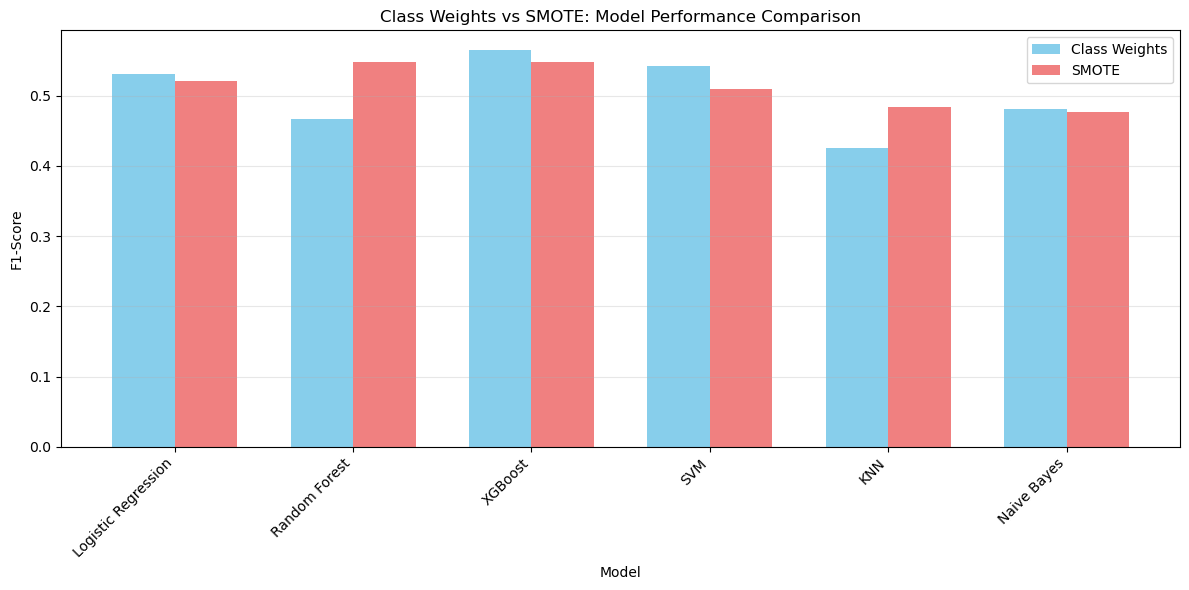


🏆 WINNER: SMOTE
   Average F1-Score: 0.5019 (Class Weights) vs 0.5148 (SMOTE)


In [26]:
# =============================================================================
# COMPARE: CLASS WEIGHTS vs SMOTE
# =============================================================================

print("\n" + "="*70)
print("TRAINING MODELS WITH SMOTE FOR COMPARISON")
print("="*70)

# Train same models with SMOTE data (without class weights)
models_smote = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

results_smote = {}

for name, model in models_smote.items():
    print(f"\nTraining {name} with SMOTE...")
    
    # Train on SMOTE data
    model.fit(X_train_smote_scaled, y_train_smote)
    
    # Predict on same test set
    y_pred = model.predict(X_test_scaled_smote)
    y_pred_proba = model.predict_proba(X_test_scaled_smote)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None
    
    results_smote[name] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'roc_auc': roc_auc
    }
    
    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}")
    if roc_auc is not None:
        print(f"  ✓ ROC-AUC:  {roc_auc:.4f}")

print("\n" + "="*70)

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Class Weights F1': [results[m]['f1_score'] for m in results.keys()],
    'SMOTE F1': [results_smote[m]['f1_score'] for m in results_smote.keys()],
    'Difference': [results_smote[m]['f1_score'] - results[m]['f1_score'] for m in results.keys()]
})

print("\n📊 CLASS WEIGHTS vs SMOTE COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False, float_format='%.4f'))
print("="*70)

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Class Weights F1'], width, 
       label='Class Weights', color='skyblue')
ax.bar(x + width/2, comparison_df['SMOTE F1'], width, 
       label='SMOTE', color='lightcoral')

ax.set_xlabel('Model')
ax.set_ylabel('F1-Score')
ax.set_title('Class Weights vs SMOTE: Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Determine winner
best_approach = "Class Weights" if comparison_df['Class Weights F1'].mean() > comparison_df['SMOTE F1'].mean() else "SMOTE"
print(f"\n🏆 WINNER: {best_approach}")
print(f"   Average F1-Score: {comparison_df['Class Weights F1'].mean():.4f} (Class Weights) vs {comparison_df['SMOTE F1'].mean():.4f} (SMOTE)")


CROSS-VALIDATION EVALUATION (5-Fold Stratified)

Evaluating Logistic Regression...
  Accuracy:  0.6621 (+/- 0.0132)
  F1-Score:  0.5337 (+/- 0.0136)
  ROC-AUC:   0.7163 (+/- 0.0136)
  Precision: 0.4584
  Recall:    0.6394

Evaluating Random Forest...
  Accuracy:  0.7256 (+/- 0.0115)
  F1-Score:  0.4377 (+/- 0.0346)
  ROC-AUC:   0.7481 (+/- 0.0138)
  Precision: 0.5738
  Recall:    0.3543
  ⚠️  Potential overfitting detected (gap: 0.2598)

Evaluating XGBoost...
  Accuracy:  0.7014 (+/- 0.0092)
  F1-Score:  0.5297 (+/- 0.0207)
  ROC-AUC:   0.7479 (+/- 0.0092)
  Precision: 0.5056
  Recall:    0.5569
  ⚠️  Potential overfitting detected (gap: 0.2625)

Evaluating SVM...
  Accuracy:  0.6489 (+/- 0.0137)
  F1-Score:  0.5349 (+/- 0.0145)
  ROC-AUC:   0.7090 (+/- 0.0141)
  Precision: 0.4465
  Recall:    0.6679

Evaluating KNN...
  Accuracy:  0.6781 (+/- 0.0077)
  F1-Score:  0.3693 (+/- 0.0170)
  ROC-AUC:   0.6280 (+/- 0.0147)
  Precision: 0.4532
  Recall:    0.3118
  ⚠️  Potential overfitting d

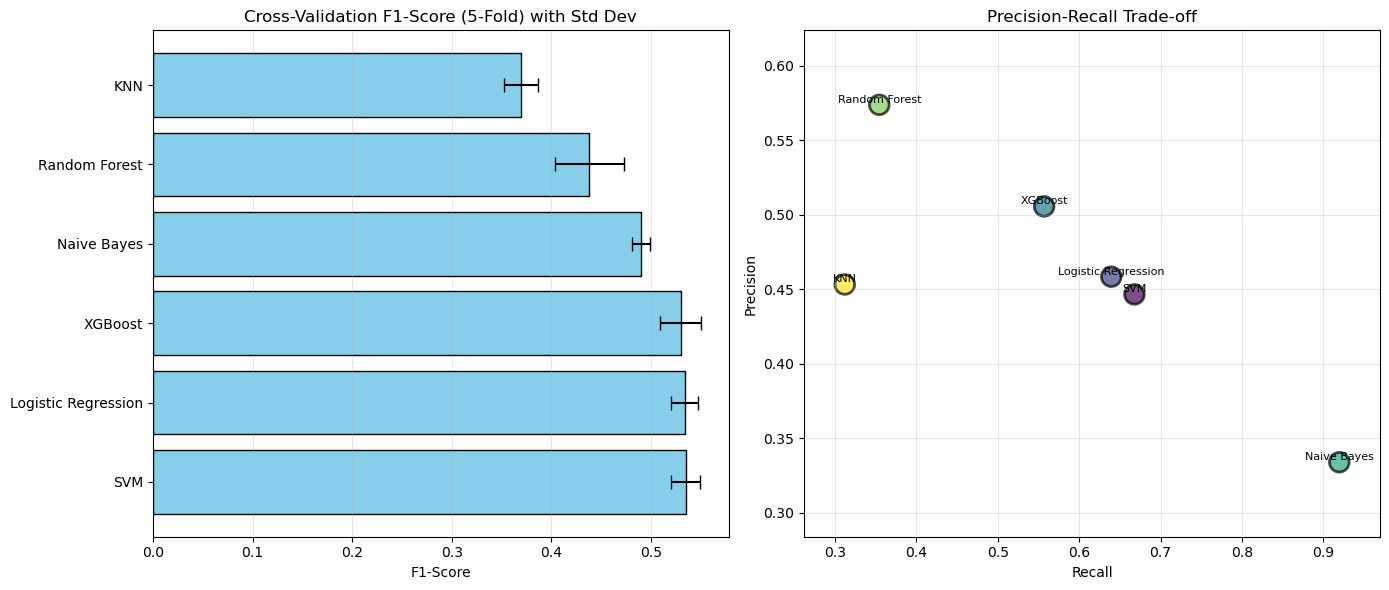


✓ Cross-validation completed. Top 3 models will undergo hyperparameter tuning.


In [28]:
# =============================================================================
# STEP 3: CROSS-VALIDATION FOR ROBUST EVALUATION
# =============================================================================

print("\n" + "="*70)
print("CROSS-VALIDATION EVALUATION (5-Fold Stratified)")
print("="*70)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall'
}

# Store cross-validation results
cv_results = {}

for name, model in models.items():
    print(f"\nEvaluating {name}...")
    
    # Perform 5-fold stratified cross-validation
    cv_scores = cross_validate(
        model, 
        X_train_scaled, 
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    
    # Calculate mean and std for each metric
    cv_results[name] = {
        'accuracy_mean': cv_scores['test_accuracy'].mean(),
        'accuracy_std': cv_scores['test_accuracy'].std(),
        'f1_mean': cv_scores['test_f1'].mean(),
        'f1_std': cv_scores['test_f1'].std(),
        'roc_auc_mean': cv_scores['test_roc_auc'].mean(),
        'roc_auc_std': cv_scores['test_roc_auc'].std(),
        'precision_mean': cv_scores['test_precision'].mean(),
        'recall_mean': cv_scores['test_recall'].mean(),
        'train_accuracy': cv_scores['train_accuracy'].mean()
    }
    
    print(f"  Accuracy:  {cv_results[name]['accuracy_mean']:.4f} (+/- {cv_results[name]['accuracy_std']:.4f})")
    print(f"  F1-Score:  {cv_results[name]['f1_mean']:.4f} (+/- {cv_results[name]['f1_std']:.4f})")
    print(f"  ROC-AUC:   {cv_results[name]['roc_auc_mean']:.4f} (+/- {cv_results[name]['roc_auc_std']:.4f})")
    print(f"  Precision: {cv_results[name]['precision_mean']:.4f}")
    print(f"  Recall:    {cv_results[name]['recall_mean']:.4f}")
    
    # Check for overfitting
    overfit_gap = cv_results[name]['train_accuracy'] - cv_results[name]['accuracy_mean']
    if overfit_gap > 0.1:
        print(f"  ⚠️  Potential overfitting detected (gap: {overfit_gap:.4f})")

print("\n" + "="*70)

# Create CV results comparison
cv_comparison_df = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Accuracy': [cv_results[m]['accuracy_mean'] for m in cv_results.keys()],
    'F1-Score': [cv_results[m]['f1_mean'] for m in cv_results.keys()],
    'ROC-AUC': [cv_results[m]['roc_auc_mean'] for m in cv_results.keys()],
    'Precision': [cv_results[m]['precision_mean'] for m in cv_results.keys()],
    'Recall': [cv_results[m]['recall_mean'] for m in cv_results.keys()]
})

cv_comparison_df = cv_comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\nCROSS-VALIDATION RESULTS SUMMARY")
print("="*70)
print(cv_comparison_df.to_string(index=False, float_format='%.4f'))
print("="*70)
# Visualize CV performance with error bars
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: F1-Score with standard deviation
models_sorted = cv_comparison_df['Model'].tolist()
f1_means = [cv_results[m]['f1_mean'] for m in models_sorted]
f1_stds = [cv_results[m]['f1_std'] for m in models_sorted]

axes[0].barh(models_sorted, f1_means, xerr=f1_stds, capsize=5, color='skyblue', edgecolor='black')
axes[0].set_xlabel('F1-Score')
axes[0].set_title('Cross-Validation F1-Score (5-Fold) with Std Dev')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Precision-Recall Trade-off
precision = [cv_results[m]['precision_mean'] for m in models_sorted]
recall = [cv_results[m]['recall_mean'] for m in models_sorted]

axes[1].scatter(recall, precision, s=200, c=range(len(models_sorted)), 
                cmap='viridis', edgecolors='black', linewidths=2, alpha=0.7)

for i, model in enumerate(models_sorted):
    axes[1].annotate(model, (recall[i], precision[i]), 
                    fontsize=8, ha='center', va='bottom')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Trade-off')
axes[1].grid(alpha=0.3)
axes[1].set_xlim([min(recall) - 0.05, max(recall) + 0.05])
axes[1].set_ylim([min(precision) - 0.05, max(precision) + 0.05])

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(f"✓ Cross-validation completed. Top 3 models will undergo hyperparameter tuning.")
print("="*70)

In [30]:
# =============================================================================
# STEP 4: HYPERPARAMETER TUNING FOR TOP 3 MODELS
# =============================================================================

# Select top 3 models based on CV F1-score
top_3_models = cv_comparison_df.head(3)['Model'].tolist()

print("\n" + "="*70)
print(f"HYPERPARAMETER TUNING - TOP 3 MODELS")
print("="*70)
print(f"Selected models: {', '.join(top_3_models)}")
print("="*70)

# Define parameter grids for each model
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto', 0.01, 0.1]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    }
}

# Store tuned models
tuned_models = {}
tuning_results = {}

for model_name in top_3_models:
    print(f"\n{'='*70}")
    print(f"Tuning {model_name}...")
    print('='*70)
    
    # Get base model
    if model_name == 'Logistic Regression':
        base_model = LogisticRegression(class_weight='balanced', random_state=42)
    elif model_name == 'Random Forest':
        base_model = RandomForestClassifier(class_weight='balanced', random_state=42)
    elif model_name == 'XGBoost':
        base_model = XGBClassifier(
            scale_pos_weight=(len(y_train[y_train==0])/len(y_train[y_train==1])),
            random_state=42,
            eval_metric='logloss'
        )
    elif model_name == 'SVM':
        base_model = SVC(class_weight='balanced', random_state=42, probability=True)
    elif model_name == 'KNN':
        base_model = KNeighborsClassifier()
    elif model_name == 'Naive Bayes':
        base_model = GaussianNB()
    
    # Grid search with stratified k-fold
    grid_search = GridSearchCV(
        base_model,
        param_grids[model_name],
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    # Fit grid search
    grid_search.fit(X_train_scaled, y_train)
    
    # Store results
    tuned_models[model_name] = grid_search.best_estimator_
    tuning_results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'cv_results': grid_search.cv_results_
    }
    
    print(f"\n✓ Best parameters found:")
    for param, value in grid_search.best_params_.items():
        print(f"    {param}: {value}")
    print(f"\n✓ Best CV F1-Score: {grid_search.best_score_:.4f}")

print("\n" + "="*70)
print("HYPERPARAMETER TUNING COMPLETED")
print("="*70)


print("\n📊 TUNING SUMMARY")
print("="*70)

tuning_summary = pd.DataFrame({
    'Model': list(tuning_results.keys()),
    'Best CV F1': [tuning_results[m]['best_score'] for m in tuning_results.keys()],
    'Baseline CV F1': [cv_results[m]['f1_mean'] for m in tuning_results.keys()],
    'Improvement': [tuning_results[m]['best_score'] - cv_results[m]['f1_mean'] 
                    for m in tuning_results.keys()]
})

print(tuning_summary.to_string(index=False, float_format='%.4f'))
print("="*70)


HYPERPARAMETER TUNING - TOP 3 MODELS
Selected models: SVM, Logistic Regression, XGBoost

Tuning SVM...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✓ Best parameters found:
    C: 10
    gamma: 0.01
    kernel: rbf

✓ Best CV F1-Score: 0.5449

Tuning Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✓ Best parameters found:
    C: 100
    max_iter: 1000
    penalty: l1
    solver: liblinear

✓ Best CV F1-Score: 0.5376

Tuning XGBoost...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

✓ Best parameters found:
    colsample_bytree: 1.0
    learning_rate: 0.05
    max_depth: 3
    n_estimators: 200
    subsample: 0.8

✓ Best CV F1-Score: 0.5999

HYPERPARAMETER TUNING COMPLETED

📊 TUNING SUMMARY
              Model  Best CV F1  Baseline CV F1  Improvement
                SVM      0.5449          0.5349       0.0100
Logistic Regression      0.5376          0.5337       0.0039
            XGBoost      0.5999          0.5


TUNED MODELS EVALUATION ON TEST SET

SVM:
  Accuracy:  0.6487
  F1-Score:  0.5559
  ROC-AUC:   0.7270

Logistic Regression:
  Accuracy:  0.6503
  F1-Score:  0.5276
  ROC-AUC:   0.7194

XGBoost:
  Accuracy:  0.6579
  F1-Score:  0.5806
  ROC-AUC:   0.7652


IMPROVEMENT AFTER TUNING
              Model  Before F1  After F1  Improvement
                SVM     0.5420    0.5559       0.0139
Logistic Regression     0.5307    0.5276      -0.0030
            XGBoost     0.5650    0.5806       0.0156


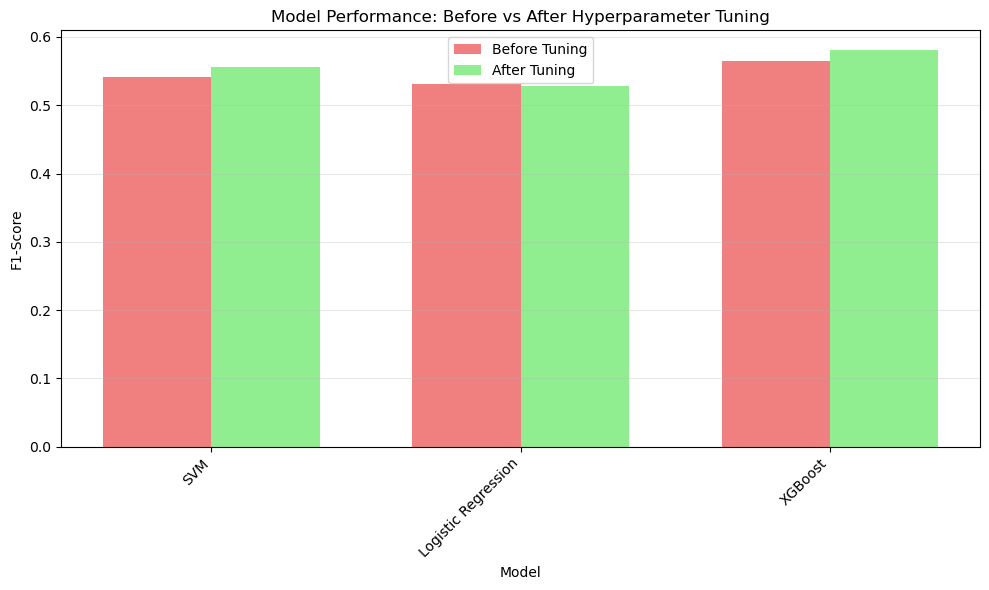

In [32]:
# =============================================================================
# STEP 5: EVALUATE TUNED MODELS ON TEST SET
# =============================================================================

print("\n" + "="*70)
print("TUNED MODELS EVALUATION ON TEST SET")
print("="*70)

tuned_results = {}

for model_name, model in tuned_models.items():
    print(f"\n{model_name}:")
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    tuned_results[model_name] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'model': model
    }
    
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")

print("\n" + "="*70)

# Compare Before vs After Tuning
print("\nIMPROVEMENT AFTER TUNING")
print("="*70)

improvement_df = pd.DataFrame({
    'Model': list(tuned_results.keys()),
    'Before F1': [results[m]['f1_score'] for m in tuned_results.keys()],
    'After F1': [tuned_results[m]['f1_score'] for m in tuned_results.keys()],
    'Improvement': [tuned_results[m]['f1_score'] - results[m]['f1_score'] 
                   for m in tuned_results.keys()]
})

print(improvement_df.to_string(index=False, float_format='%.4f'))
print("="*70)

# Visualize improvement
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(improvement_df))
width = 0.35

ax.bar(x - width/2, improvement_df['Before F1'], width, label='Before Tuning', color='lightcoral')
ax.bar(x + width/2, improvement_df['After F1'], width, label='After Tuning', color='lightgreen')

ax.set_xlabel('Model')
ax.set_ylabel('F1-Score')
ax.set_title('Model Performance: Before vs After Hyperparameter Tuning')
ax.set_xticks(x)
ax.set_xticklabels(improvement_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


FINAL BEST MODEL: XGBoost

Best Hyperparameters:
  colsample_bytree: 1.0
  learning_rate: 0.05
  max_depth: 3
  n_estimators: 200
  subsample: 0.8

Performance Metrics:
  Accuracy:  0.6579
  F1-Score:  0.5806
  ROC-AUC:   0.7652

Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.87      0.60      0.71      1279
     Popular       0.46      0.78      0.58       554

    accuracy                           0.66      1833
   macro avg       0.66      0.69      0.65      1833
weighted avg       0.74      0.66      0.67      1833



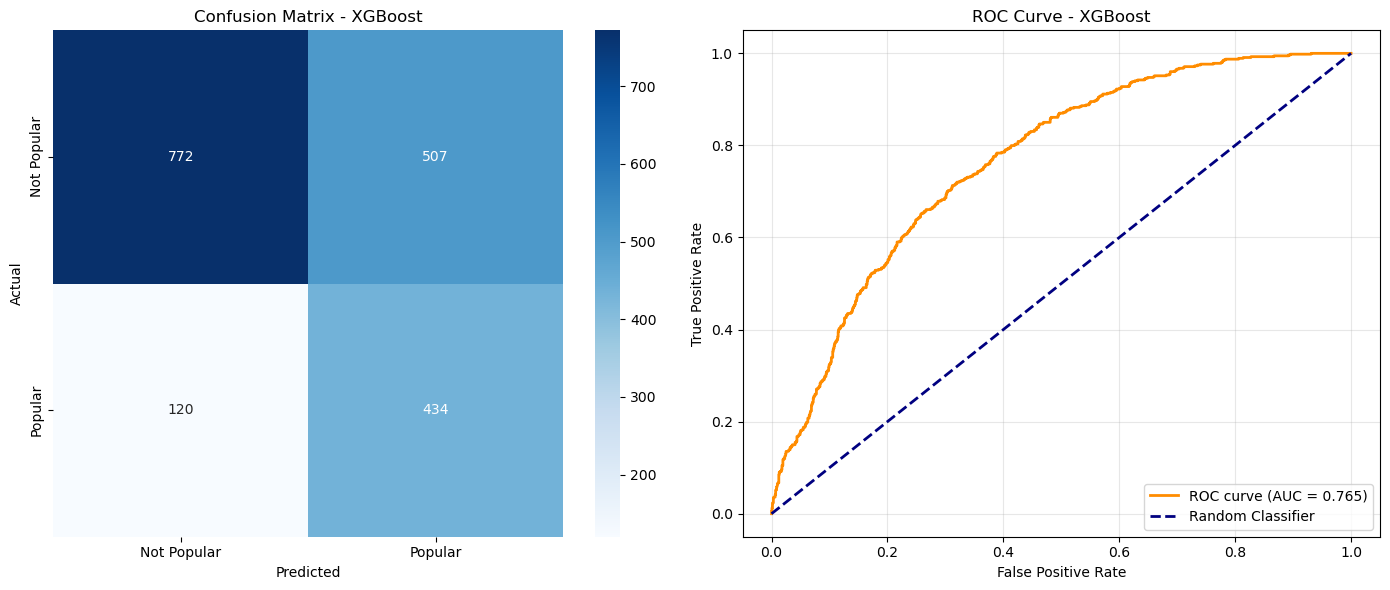

In [33]:
# =============================================================================
# FINAL BEST MODEL SELECTION AND DETAILED EVALUATION
# =============================================================================

# Select best tuned model
best_tuned_model_name = max(tuned_results.items(), key=lambda x: x[1]['f1_score'])[0]
best_tuned_model = tuned_results[best_tuned_model_name]

print("\n" + "="*70)
print(f"FINAL BEST MODEL: {best_tuned_model_name}")
print("="*70)

print("\nBest Hyperparameters:")
for param, value in tuning_results[best_tuned_model_name]['best_params'].items():
    print(f"  {param}: {value}")

print("\nPerformance Metrics:")
print(f"  Accuracy:  {best_tuned_model['accuracy']:.4f}")
print(f"  F1-Score:  {best_tuned_model['f1_score']:.4f}")
print(f"  ROC-AUC:   {best_tuned_model['roc_auc']:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, best_tuned_model['predictions'],
                          target_names=['Not Popular', 'Popular']))

# Final visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, best_tuned_model['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'],
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_tuned_model_name}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_tuned_model['probabilities'])
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
            label=f'ROC curve (AUC = {best_tuned_model["roc_auc"]:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
            label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve - {best_tuned_model_name}')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("="*70)